In [1]:
import pickle

def load_from_pickle(pickle_path):
    with open(pickle_path, 'rb') as f:
        text = pickle.load(f)
    return text

lemma_1001 = load_from_pickle('pickles_lemma/1001_lemma_clean.pkl')
lemma_ALC = load_from_pickle('pickles_lemma/ALC_lemma_clean.pkl')
lemma_BTEC = load_from_pickle('pickles_lemma/BTEC_lemma_clean.pkl')
lemma_Hadith = load_from_pickle('pickles_lemma/Hadith_lemma_clean.pkl')
lemma_Hayy = load_from_pickle('pickles_lemma/Hayy_lemma_clean.pkl')
lemma_NT = load_from_pickle('pickles_lemma/NT_lemma_clean.pkl')
lemma_Odes = load_from_pickle('pickles_lemma/Odes_lemma_clean.pkl')
lemma_OT = load_from_pickle('pickles_lemma/OT_lemma_clean.pkl')
lemma_QALB = load_from_pickle('pickles_lemma/QALB_lemma_clean.pkl')
lemma_Quran = load_from_pickle('pickles_lemma/Quran_lemma_clean.pkl')
lemma_Sara = load_from_pickle('pickles_lemma/Sara_lemma_clean.pkl')
lemma_Wikinews = load_from_pickle('pickles_lemma/Wikinews_lemma_clean.pkl')
lemma_ZAEBUC = load_from_pickle('pickles_lemma/ZAEBUC_lemma_clean.pkl')

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

corpus = {
    "1001":     lemma_1001,
    "ALC":      lemma_ALC,
    "BTEC":     lemma_BTEC,
    "Hadith":   lemma_Hadith,
    "Hayy":     lemma_Hayy,
    "NT":       lemma_NT,
    "Odes":     lemma_Odes,
    "OT":       lemma_OT,
    "QALB":     lemma_QALB,
    "Quran":    lemma_Quran,
    "Sara":     lemma_Sara,
    "Wikinews": lemma_Wikinews,
    "ZAEBUC":   lemma_ZAEBUC,
}

docs   = [" ".join(lemmas) if isinstance(lemmas, list) else lemmas for lemmas in corpus.values()]
labels = list(corpus.keys())

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=labels
)

print(df.shape) 
# print(df)
df.to_csv("document_feature_matrix.csv")

#print top 10 words by frequency for each document
for label in labels:
    doc_vector = X[labels.index(label)].toarray().flatten()
    word_freq = dict(zip(vectorizer.get_feature_names_out(), doc_vector))
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top 10 words in {label}:")
    for word, freq in top_words:
        print(f"  {word}: {freq}")

(13, 28838)
Top 10 words in 1001:
  قال: 286
  الملك: 117
  ملك: 89
  الله: 82
  فقال: 57
  فلما: 55
  وزير: 53
  أمر: 49
  دخل: 47
  كلام: 47
Top 10 words in ALC:
  الله: 98
  يوم: 71
  رحلة: 46
  مدينة: 43
  ساعة: 29
  آخر: 25
  قال: 24
  أمي: 23
  عندما: 23
  كثير: 23
Top 10 words in BTEC:
  فضلك: 255
  أراد: 132
  أمكن: 111
  غرفة: 61
  امكنى: 54
  يوم: 52
  رقم: 51
  حسن: 48
  آخر: 46
  ساعة: 41
Top 10 words in Hadith:
  قال: 560
  الله: 442
  حدثنا: 257
  بن: 246
  عنى: 218
  صلى: 195
  منن: 191
  سلم: 188
  عبد: 122
  رسال: 119
Top 10 words in Hayy:
  جسم: 199
  شيء: 170
  فعل: 93
  صورة: 89
  حيوان: 88
  آخر: 73
  وجود: 73
  نظر: 64
  قوة: 61
  معنى: 56
Top 10 words in NT:
  منن: 161
  إل: 104
  قال: 64
  يسوع: 52
  الأ: 38
  قدد: 34
  لميم: 26
  الإذوي: 25
  أرض: 24
  إأن: 24
Top 10 words in Odes:
  منن: 74
  قدد: 22
  يوم: 21
  قال: 15
  عنى: 12
  أمر: 9
  إأن: 9
  بن: 9
  رب: 9
  علي: 9
Top 10 words in OT:
  منن: 160
  أرض: 134
  إل: 92
  قال: 67
  الله: 53
  الرب: 50
  أبرا

In [3]:
with open("document_feature_matrix.pkl", "wb") as f:
    pickle.dump(df, f)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(docs)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=labels
)

top_n = 10
for doc_name in tfidf_df.index:
    top_terms = (tfidf_df.loc[doc_name]
                 .sort_values(ascending=False)
                 .head(top_n))
    print(f"\n--- {doc_name} ---")
    print(top_terms.to_string())


--- 1001 ---
الملك      0.451664
قال        0.434596
وزير       0.237255
فلما       0.188277
ملك        0.167857
صياد       0.165631
فقال       0.160004
الحكيم     0.135113
الله       0.133839
العفريت    0.129819

--- ALC ---
الله     0.313583
رحلة     0.278132
يوم      0.227188
مدينة    0.184698
أمي      0.139066
رياض     0.121090
ذهبنا    0.114088
سيارة    0.100880
ساعة     0.099710
عندما    0.098792

--- BTEC ---
فضلك       0.797521
أمكن       0.183790
امكنى      0.168887
أراد       0.161741
غرفة       0.131440
رقم        0.100021
ياباني     0.087571
فندق       0.083708
اليابان    0.075518
حقيبة      0.072821

--- Hadith ---
حدثنا    0.545995
قال      0.403854
الله     0.342378
صلى      0.238103
بن       0.220191
منن      0.198602
سلم      0.195483
رسال     0.193330
عنى      0.157214
لوئ      0.123221

--- Hayy ---
جسم      0.383992
شيء      0.282378
حيوان    0.199403
صورة     0.171735
وجود     0.165414
فعل      0.154477
معنى     0.138445
جملة     0.122396
تشبه     0.118275
يقظان  

C:\Users\yichy\AppData\Local\Temp\ipykernel_40756\508607769.py:44: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yichy\AppData\Local\Temp\ipykernel_40756\508607769.py:45: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=500, bbox_inches="tight")
c:\Spring 2026\IDS570\IDS570_Text_as_Data\Data_Exploration\arabiyya\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


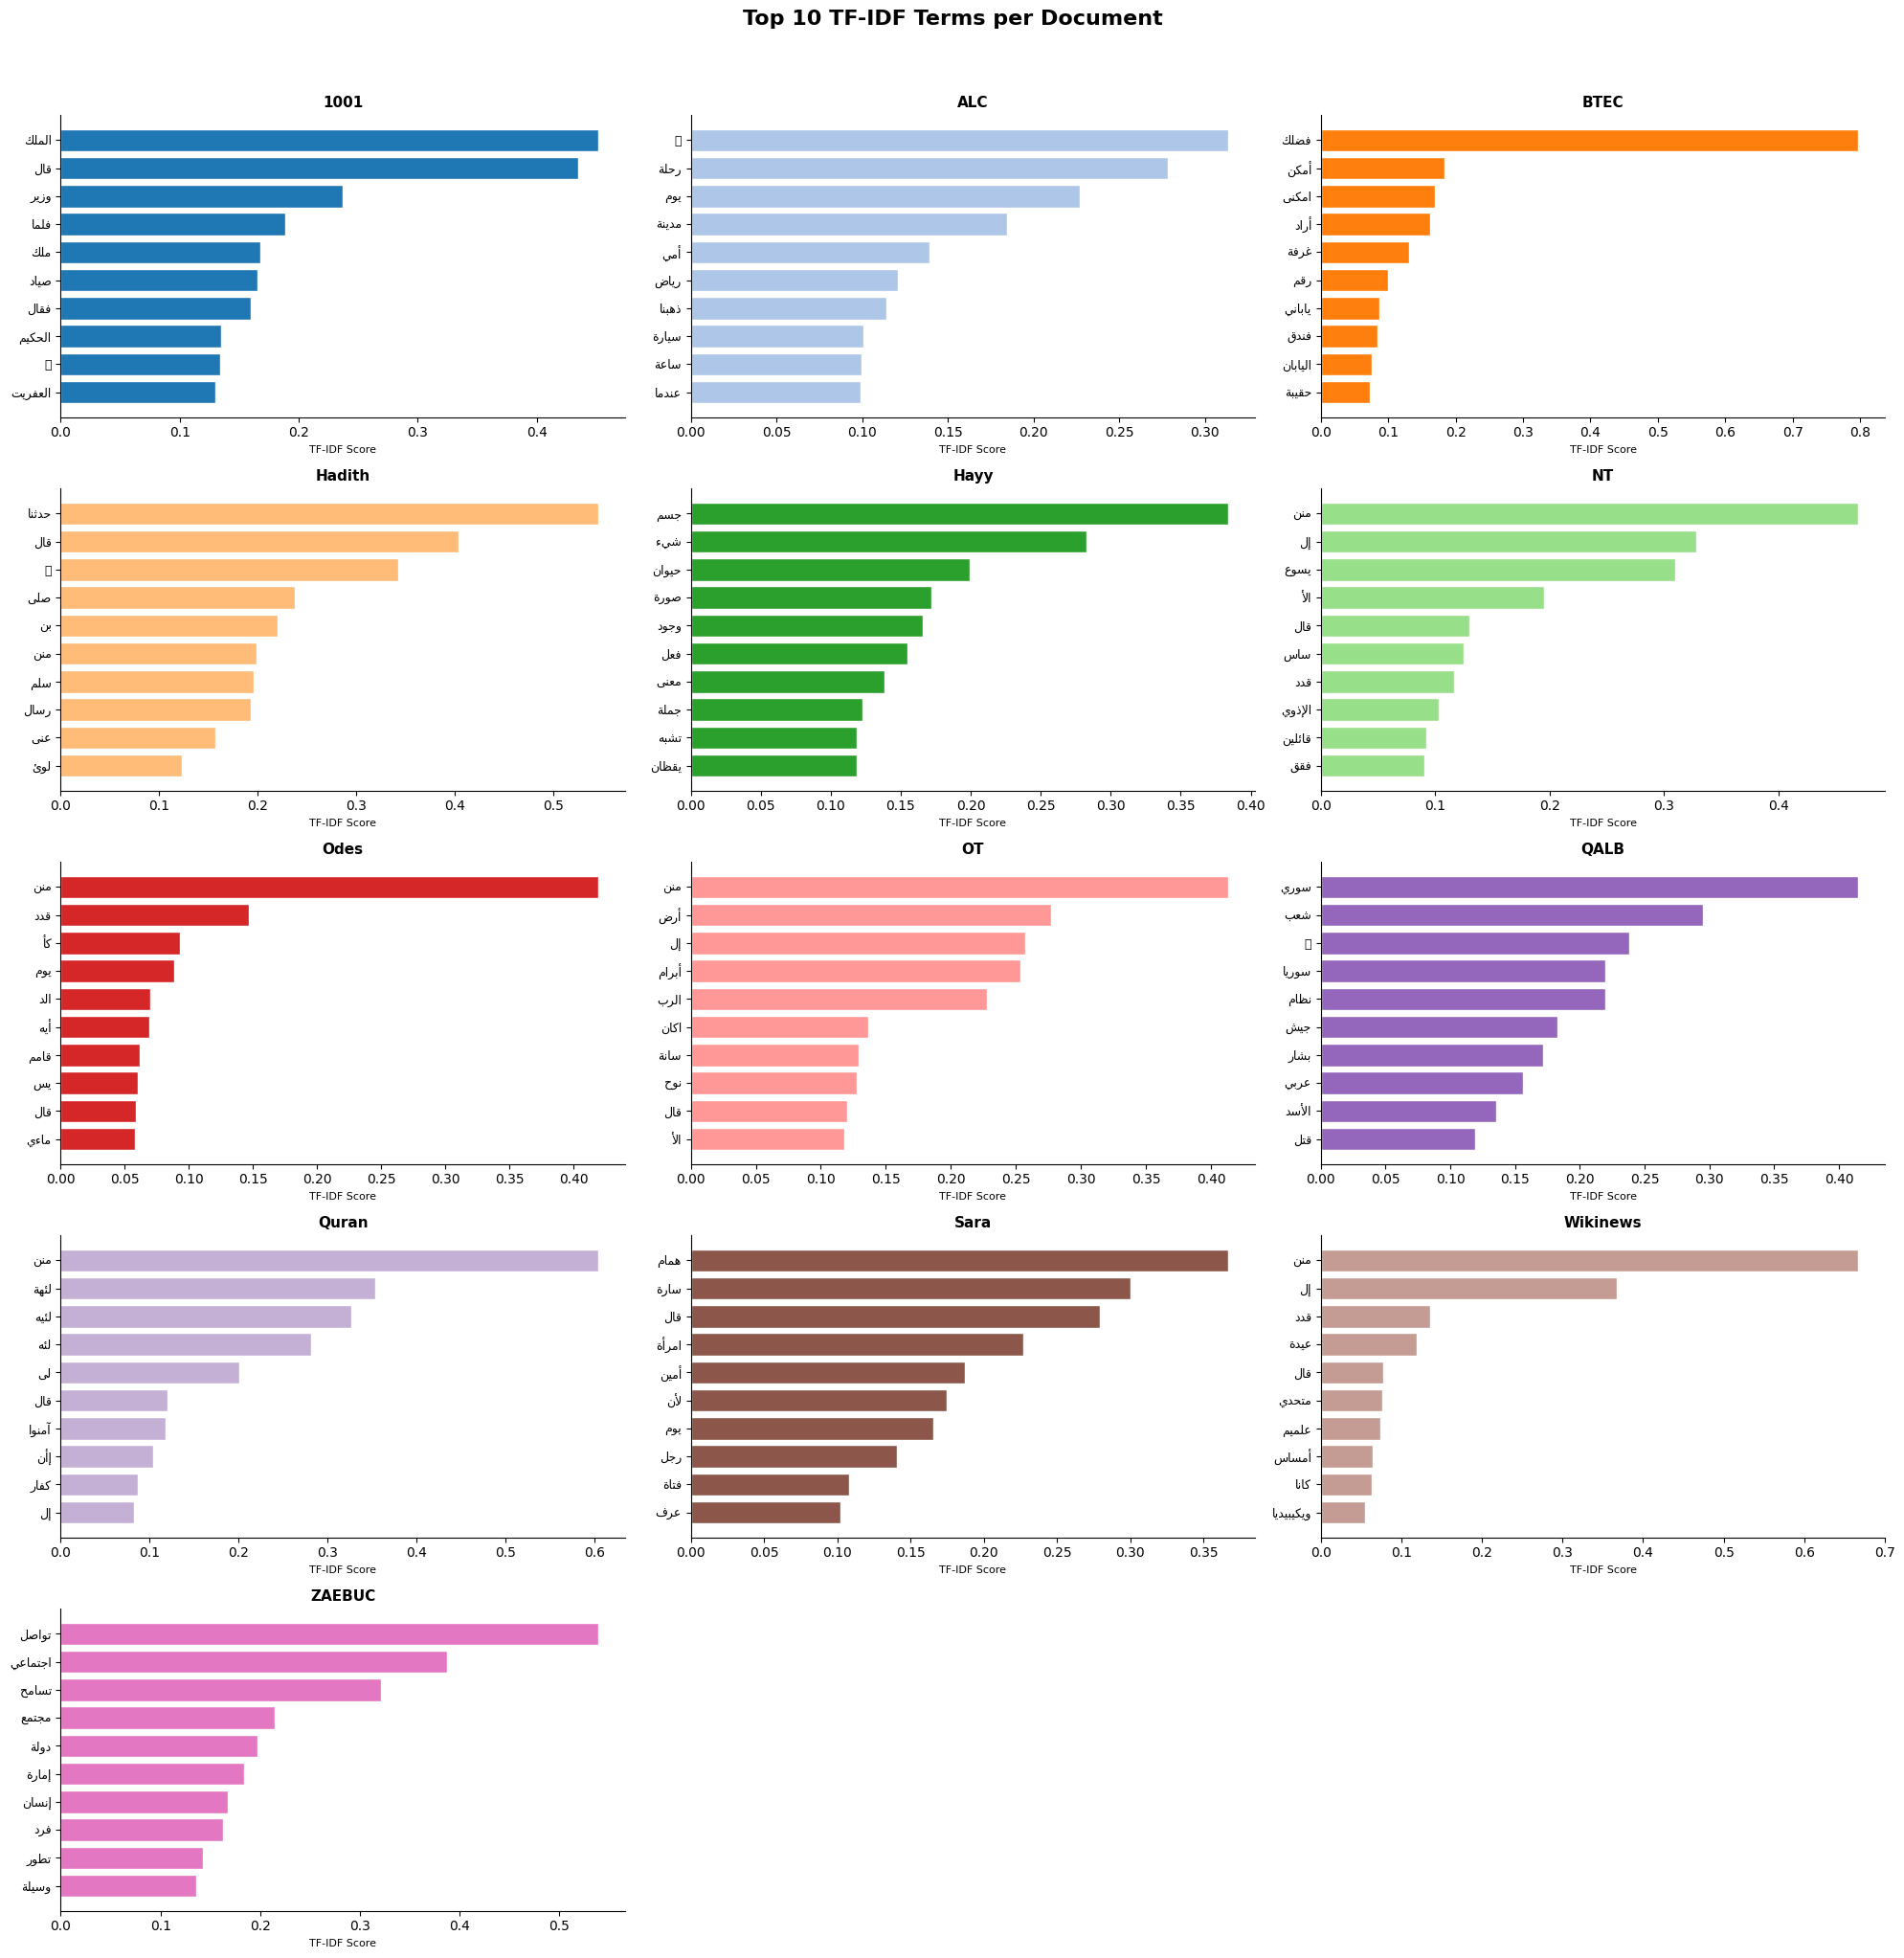

C:\Users\yichy\AppData\Local\Temp\ipykernel_40756\508607769.py:44: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yichy\AppData\Local\Temp\ipykernel_40756\508607769.py:45: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=500, bbox_inches="tight")
c:\Spring 2026\IDS570\IDS570_Text_as_Data\Data_Exploration\arabiyya\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


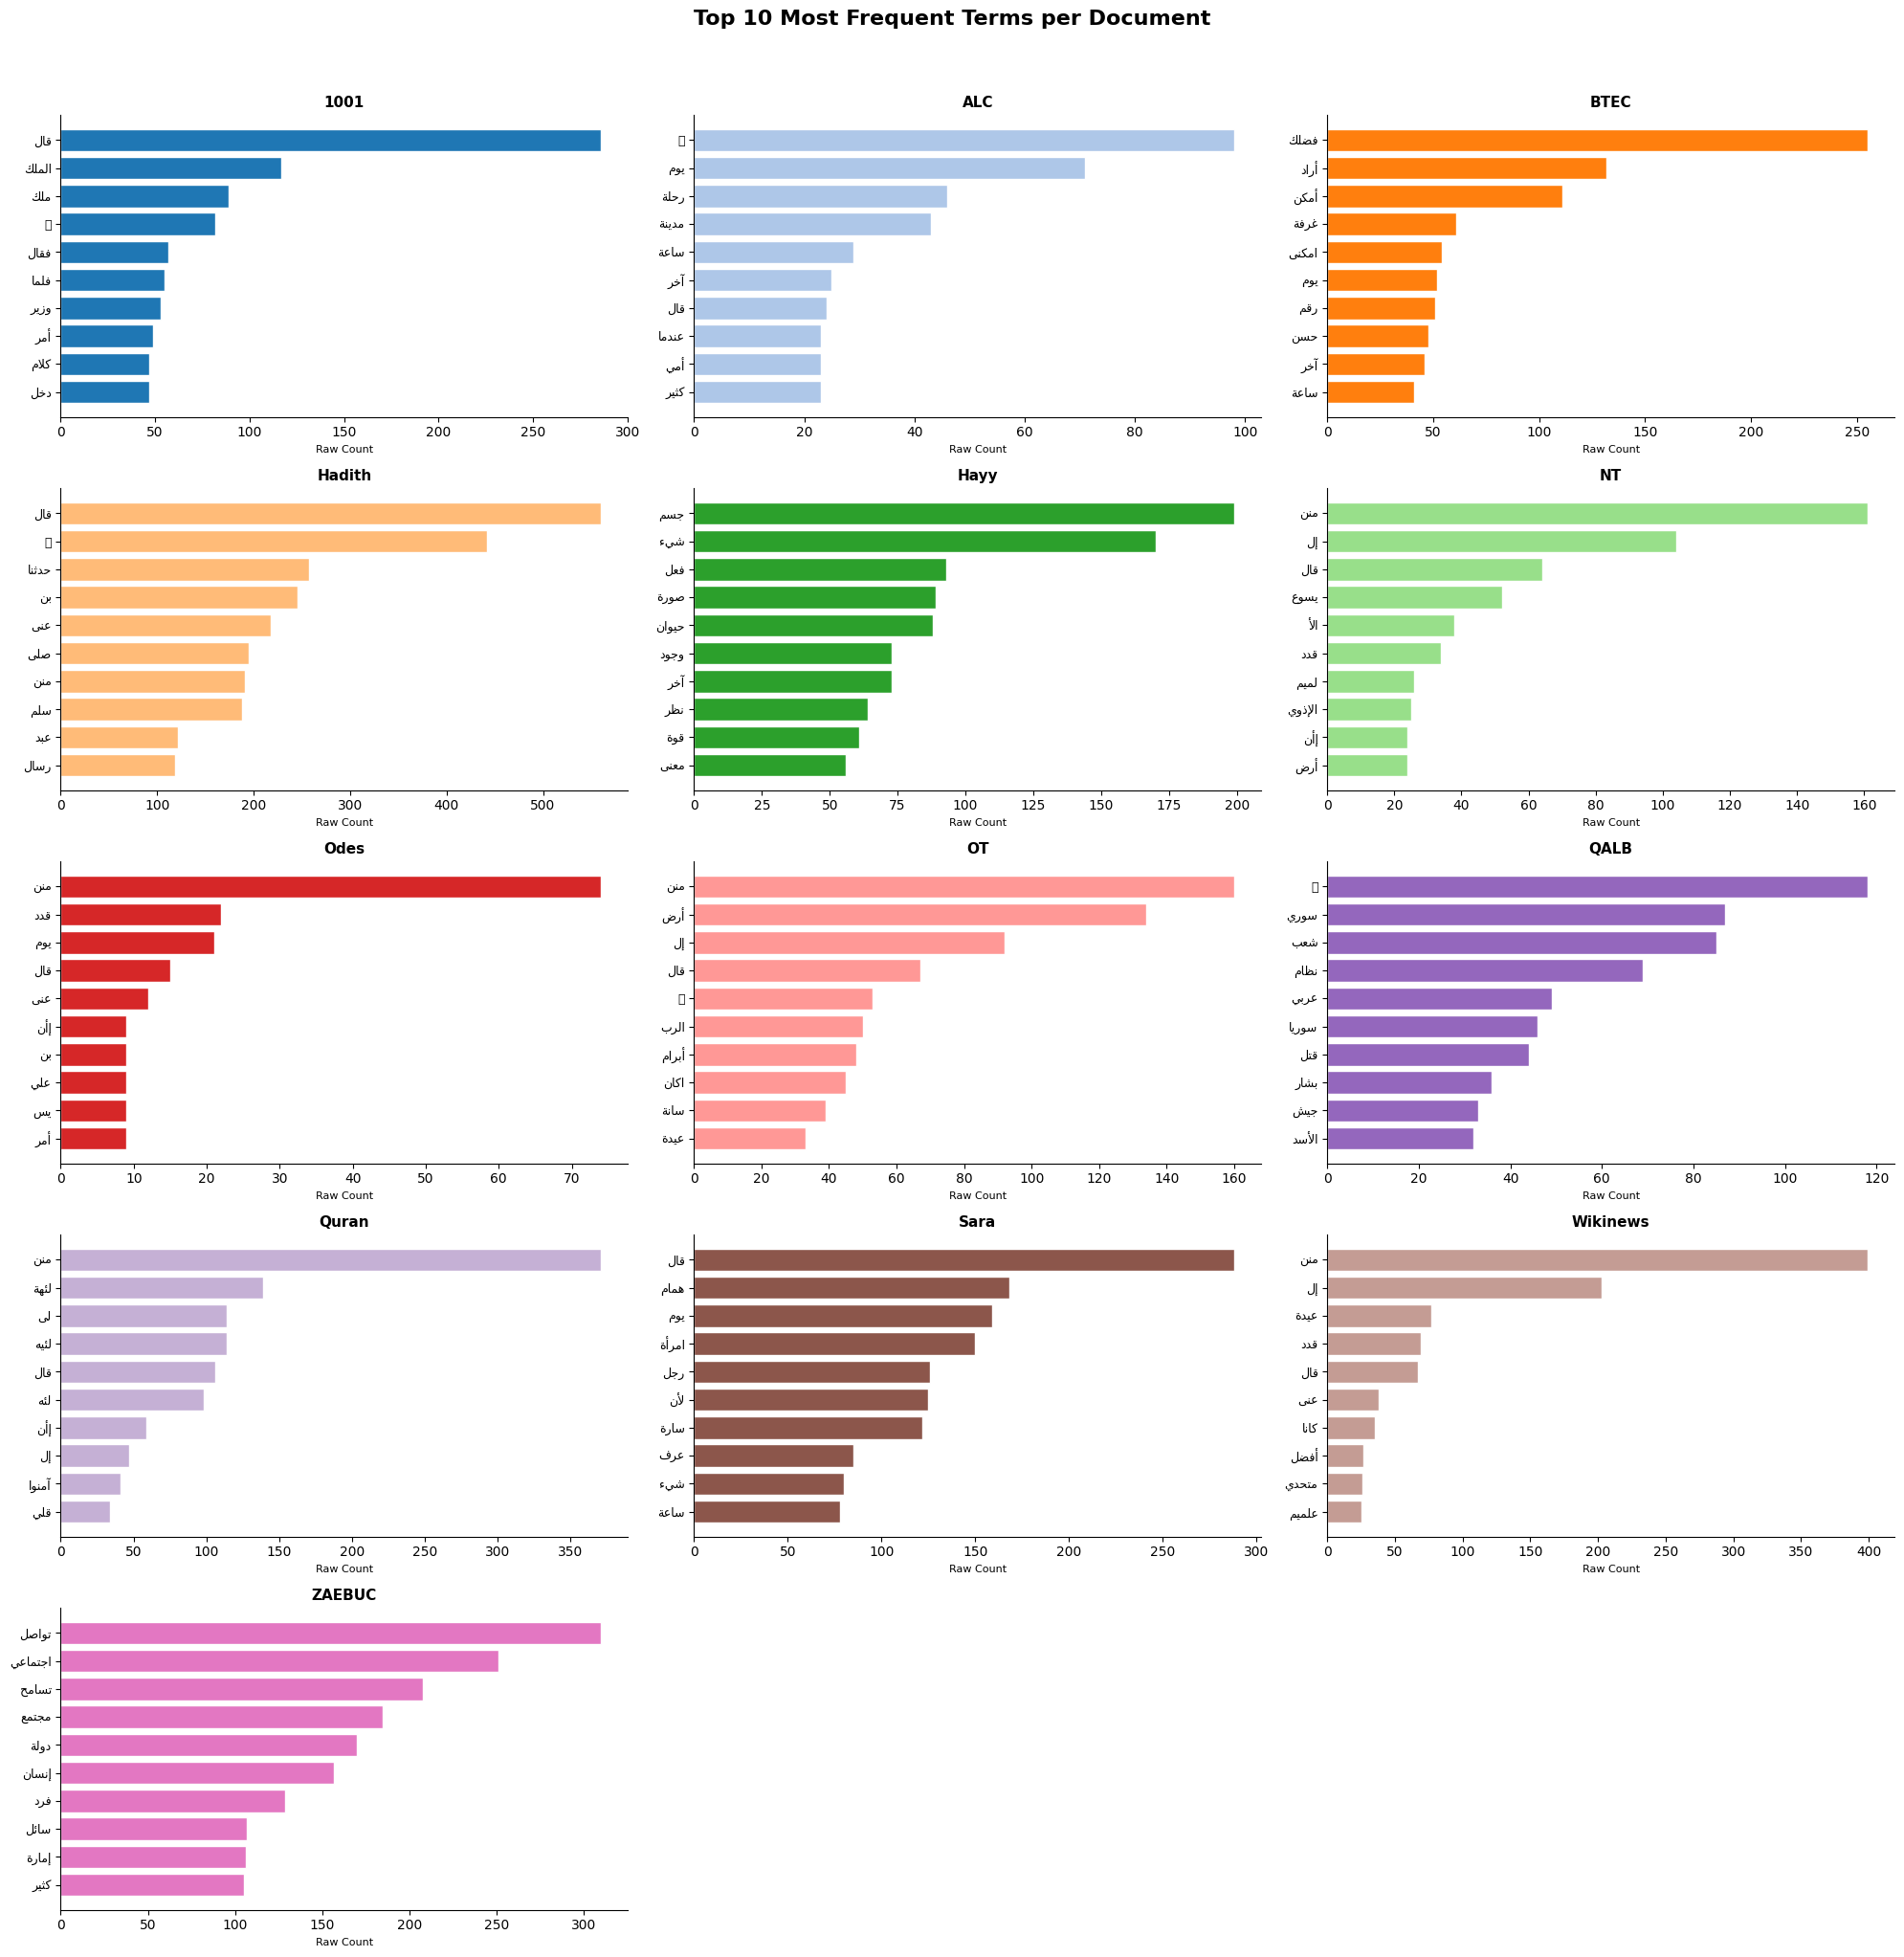

In [5]:
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np

def fix_arabic(text):
    try:
        reshaped = arabic_reshaper.reshape(text)
        return get_display(reshaped)
    except:
        return text

def plot_top_terms(source_df, title, xlabel, filename, top_n=10):
    top_data = {}
    for doc_name in source_df.index:
        top = source_df.loc[doc_name].sort_values(ascending=False).head(top_n)
        top_data[doc_name] = {"terms": top.index.tolist(), "scores": top.values.tolist()}

    n_docs = len(top_data)
    n_cols = 3
    n_rows = -(-n_docs // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = axes.flatten()
    colors = plt.cm.tab20.colors

    for i, (doc_name, data) in enumerate(top_data.items()):
        ax = axes[i]
        fixed_terms = [fix_arabic(t) for t in data["terms"]]
        y_pos = np.arange(len(fixed_terms))

        ax.barh(y_pos, data["scores"], color=colors[i], edgecolor="white")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(fixed_terms, fontsize=9)
        ax.invert_yaxis()
        ax.set_title(doc_name, fontweight="bold", fontsize=11)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=500, bbox_inches="tight")
    plt.show()

plot_top_terms(tfidf_df, "Top 10 TF-IDF Terms per Document",  "TF-IDF Score", "analysis_images/tfidf_top10.png")
plot_top_terms(df,       "Top 10 Most Frequent Terms per Document", "Raw Count",    "analysis_images/rawcount_top10.png")